In [4]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from lightgbm import LGBMClassifier

import shap
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Generate Synthetic Dataset

## Generate customer-level churn behavior

In [5]:
N_CUSTOMERS = 5000
START_DATE = pd.Timestamp("2024-01-01")
END_DATE = pd.Timestamp("2025-03-01")

CHURN_RATE = 0.12   # ~12% churn


customers = pd.DataFrame({
    "customer_id": range(N_CUSTOMERS),
    "is_churner": np.random.rand(N_CUSTOMERS) < CHURN_RATE
})

customers.sample(20).sort_values(by="is_churner").head(20)

,customer_id,is_churner
4572,4572,False
3136,3136,False
2187,2187,False
3475,3475,False
196,196,False
4779,4779,False
3044,3044,False
3809,3809,False
2272,2272,False
2753,2753,False


In [6]:
customers.value_counts("is_churner")

is_churner
False    4416
True      584
Name: count, dtype: int64

## Generate transactions for each customer

In [7]:
transactions = []

# Logic:
# - Churner: hoạt động giảm dần trước ngày churn
# - Non-churner: hoạt động ổn định đến cuối kỳ

for _, row in customers.iterrows():
    cid = row["customer_id"]
    is_churner = row["is_churner"]

    # base activity intensity
    # Mỗi khách hàng có mức độ active tự nhiên khác nhau
    #     Có người 1–2 giao dịch / tuần
    #     Có người vài giao dịch / tháng
    #     Phản ánh heterogeneity giữa khách hàng
    base_lambda = np.random.uniform(0.05, 0.3)   # events per day

    # churn date
    # Churner: có một mốc thời gian “chết”
    # Non-churner: còn sống đến cuối observation window
    if is_churner:
        churn_date = START_DATE + pd.Timedelta(
            days=np.random.randint(200, 380)
        )
    else:
        churn_date = END_DATE

    current_date = START_DATE

    while current_date <= churn_date:
        if is_churner:
            # activity decay for churners
            # > 90 ngày trước churn
            # → activity gần như bình thường

            # 90 → 0 ngày trước churn
            # → activity giảm tuyến tính

            # Sát ngày churn
            # → chỉ còn ~10% activity ban đầu

            # Đây là early churn signal:
            #     Giảm frequency
            #     Giảm engagement
            #     Trước khi biến mất hoàn toàn
            days_to_churn = (churn_date - current_date).days
            lambda_t = base_lambda * max(days_to_churn / 90, 0.1)
        else:
            # Với non-churner
            # Không có decay
            # → Hành vi ổn định theo thời gian
            lambda_t = base_lambda

        # Mỗi ngày là một Bernoulli–Poisson process
        # Khách hàng mỗi ngày có thể phát sinh 0, 1 hoặc nhiều giao dịch
        n_events = np.random.poisson(lambda_t)

        for _ in range(n_events):
            transactions.append({
                "customer_id": cid,
                "event_time": current_date,
                # Phân phối lệch phải, phù hợp dữ liệu chi tiêu / giao dịch thực tế
                "amount": np.random.gamma(2.0, 20.0)
            })

        current_date += pd.Timedelta(days=1)


# Create dataframe
transactions = pd.DataFrame(transactions)
transactions = transactions.sort_values(["customer_id", "event_time"])
transactions.to_csv("transactions.csv", index=False)

transactions.head()

,customer_id,event_time,amount
0,0,2024-01-01,66.572911
1,0,2024-01-30,9.536836
2,0,2024-02-08,59.915362
3,0,2024-02-09,42.552806
4,0,2024-02-10,23.101809


In [8]:
print("Total transactions:", len(transactions))
print("Unique customers:", transactions["customer_id"].nunique())

Total transactions: 377339
Unique customers: 5000


## Check churn behavior visually

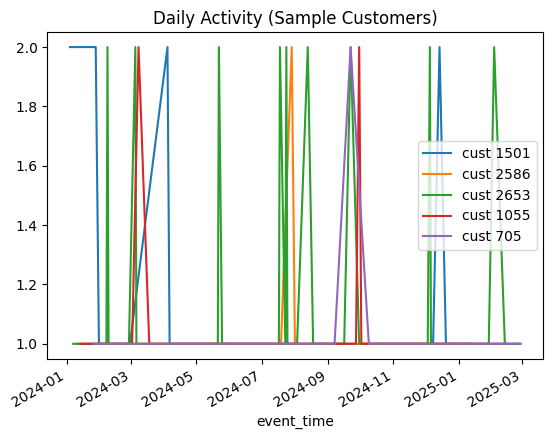

In [9]:
import matplotlib.pyplot as plt


sample_ids = customers.sample(5, random_state=42)["customer_id"]

for cid in sample_ids:
    hist = transactions[transactions["customer_id"] == cid]
    daily = hist.groupby("event_time").size()
    daily.plot(label=f"cust {cid}")

plt.legend()
plt.title("Daily Activity (Sample Customers)")
plt.show()


# Load Dataset


In [10]:
df = pd.read_csv("transactions.csv", parse_dates=["event_time"])
df = df.sort_values(["customer_id", "event_time"])


# Define cutoff date, các dữ liệu trước hoặc bằng ngày này được dùng để trích xuất đặc trưng.
CUTOFF_DATE = pd.Timestamp("2025-01-01")
PRED_WINDOW = 30

def label_churn(df, cutoff_date, pred_window=30):
    future = df[
        (df["event_time"] > cutoff_date) &
        (df["event_time"] <= cutoff_date + timedelta(days=pred_window))
    ]
    active_customers = future["customer_id"].unique()
    
    labels = (
        df[df["event_time"] <= cutoff_date]
        [["customer_id"]]
        .drop_duplicates()
    )
    labels["churn"] = ~labels["customer_id"].isin(active_customers)
    return labels


labels = label_churn(df, CUTOFF_DATE, PRED_WINDOW)

labels.head()

,customer_id,churn
0,0,False
77,1,False
165,2,False
198,3,False
311,4,True


In [11]:
labels.value_counts("churn")

churn
False    4281
True      719
Name: count, dtype: int64

# Feature engineering (RFM + rolling)

In [12]:
def build_features(df, cutoff_date):
    hist = df[df["event_time"] <= cutoff_date]

    agg = hist.groupby("customer_id").agg(
        recency_days=("event_time", lambda x: (cutoff_date - x.max()).days),
        freq_30d=("event_time", lambda x: (x >= cutoff_date - timedelta(days=30)).sum()), # tần suất giao dịch trong 30 ngày gần nhất
        freq_90d=("event_time", lambda x: (x >= cutoff_date - timedelta(days=90)).sum()), # tần suất giao dịch trong 90 ngày gần nhất
        monetary_90d=("amount", lambda x: x[x.index >= x.index.max() - 90].sum()), # tổng giá trị giao dịch trong 90 ngày gần nhất
    )

    agg["freq_ratio"] = agg["freq_30d"] / (agg["freq_90d"] + 1e-6) # tỉ lệ tần suất 30d/90d, phản ánh xu hướng tăng giảm hoạt động. nếu cao, khách hàng có xu hướng tăng hoạt động gần đây, nếu thấp, có thể đang giảm dần -> dễ churn.
    return agg.reset_index()

features = build_features(df, CUTOFF_DATE)
data = features.merge(labels, on="customer_id")

data.head()


,customer_id,recency_days,freq_30d,freq_90d,monetary_90d,freq_ratio,churn
0,0,2,8,18,2712.633210,0.444444,False
1,1,3,6,24,3124.294047,0.250000,False
2,2,3,5,9,940.518212,0.555555,False
3,3,1,10,27,3637.989187,0.370370,False
4,4,66,0,1,3561.251920,0.000000,True


In [13]:
train = data[data["customer_id"].isin(data["customer_id"].sample(frac=0.7, random_state=42))]
test = data[~data["customer_id"].isin(train["customer_id"])]

X_train = train.drop(columns=["customer_id", "churn"])
y_train = train["churn"].astype(int)

X_test = test.drop(columns=["customer_id", "churn"])
y_test = test["churn"].astype(int)


# LightGBM Baseline

In [14]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 495, number of negative: 3005
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.141429 -> initscore=-1.803475
[LightGBM] [Info] Start training from score -1.803475
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## LightGBM feature importance

In [15]:
imp = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

imp


,feature,importance
3,monetary_90d,2167
0,recency_days,1127
2,freq_90d,843
4,freq_ratio,627
1,freq_30d,319


## SHAP explainability

c:\Users\Administrator\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


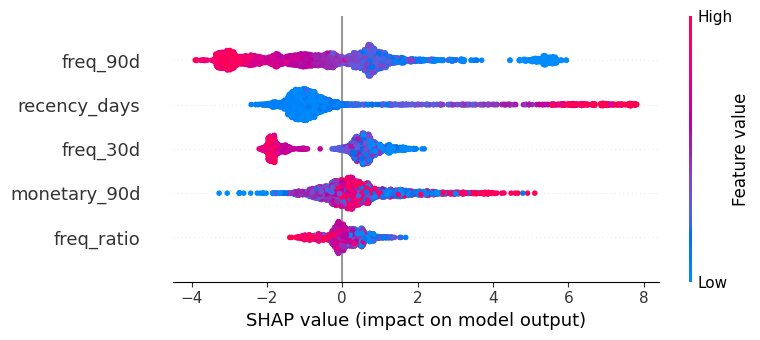

In [16]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)


# Handle Imbalanced Data

In [17]:
model_weighted = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    class_weight={0: 1, 1: 5}, # tăng độ quan trọng của lớp churner (1) để model chú ý hơn đến việc dự đoán chính xác nhóm này
    random_state=42
)

model_weighted.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 495, number of negative: 3005
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011725 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 3500, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.451642 -> initscore=-0.194037
[LightGBM] [Info] Start training from score -0.194037
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,"{0: 1, 1: 5}"
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## SMOTE oversampling

In [18]:
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

model_smote = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model_smote.fit(X_sm, y_sm)


[LightGBM] [Info] Number of positive: 3005, number of negative: 3005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001870 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 772
[LightGBM] [Info] Number of data points in the train set: 6010, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Evaluation (AUC, PR-AUC)

In [19]:
def evaluate(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    return {
        "AUC": roc_auc_score(y, proba),
        "PR_AUC": average_precision_score(y, proba)
    }


print(evaluate(model, X_test, y_test))
print(evaluate(model_weighted, X_test, y_test))
print(evaluate(model_smote, X_test, y_test))


{'AUC': 0.9486834555530677, 'PR_AUC': 0.8865998399890754}
{'AUC': 0.9489563507613076, 'PR_AUC': 0.8833387241835094}
{'AUC': 0.950899854455889, 'PR_AUC': 0.893034153868665}
